<a href="https://colab.research.google.com/github/himanshira/Machine-Learning/blob/main/Uncovering_Hidden_Country_Segments_for_Global_Development_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Task**
Analyze the socio-economic indicators of countries from the "Country-data.csv" dataset to identify distinct country segments. This analysis should include data preprocessing (outlier handling, scaling), dimensionality reduction using PCA, and a comparison of clustering techniques (K-Means, Hierarchical, DBSCAN). Finally, interpret the results to propose actionable policy recommendations and provide an executive summary of the findings.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.decomposition import PCA

In [ ]:
data = '......./Uncovering Hidden Country Segments for Global Development Strategy/Country-data.csv'
data_df_1 = pd.read_csv(data)
data_df_1.info()

data_original = data_df_1.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
data_df_1.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Summary Stats

In [ ]:
data_df_1.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


#Data Preprocessing & EDA

Detail the steps for handling outliers (e.g., using IQR capping), visualizing data distributions (histograms, boxplots), analyzing skewness, and exploring feature relationships through correlation heatmaps and pairplots. Also, include identifying top/bottom countries for key indicators.


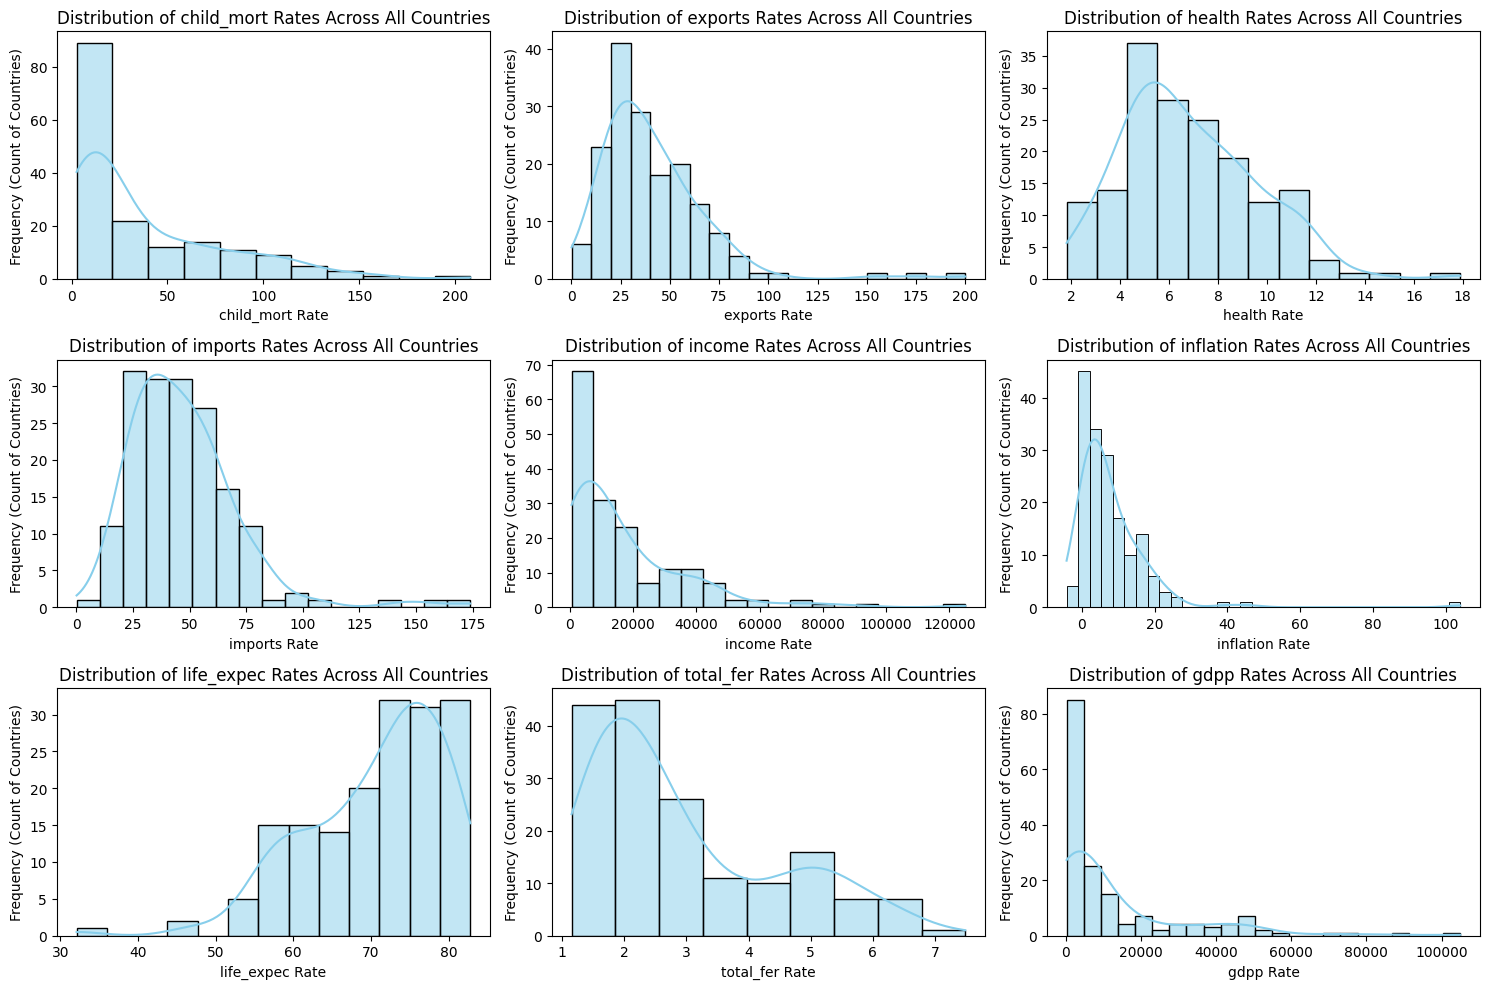

In [ ]:
plt.figure(figsize=(15, 10)) # Create a single figure for all subplots
for i, col in enumerate(data_df_1.columns[1:]): # Corrected iteration and skipped 'country' column
  plt.subplot(3, 3, i+1) # Assuming max 9 numerical columns, adjust subplot grid as needed
  sns.histplot(x=data_df_1[col], data=data_df_1, kde=True, color='skyblue')

  plt.title(f"Distribution of {col} Rates Across All Countries")
  plt.xlabel(f"{col} Rate")
  plt.ylabel("Frequency (Count of Countries)")
plt.tight_layout()
plt.show()

## Outlier Handling

Because we cannot use IQR capping to trim outliers we will use LOg TRansformation scaling. IQR will hide the critical data points by capping the data for countries in crisis or the extremely wealthy nations.




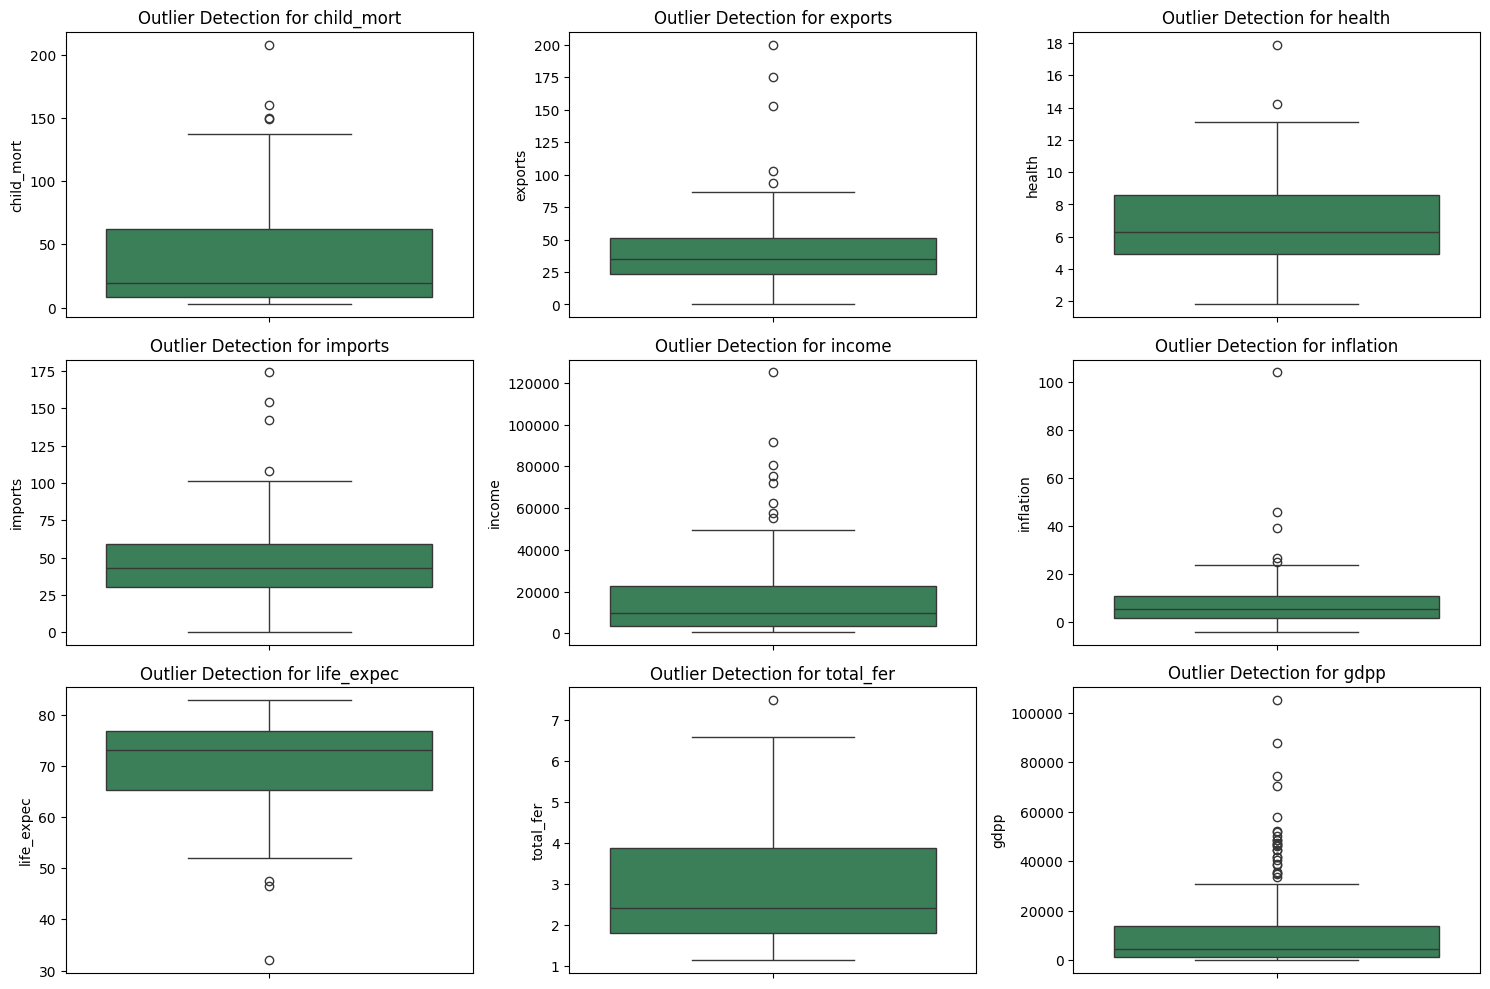

Individual box plots for outlier detection generated.


In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(data_df_1.columns[1:]):
    plt.subplot(3, 3, i + 1)  # Assuming max 9 numerical columns, adjust subplot grid as needed
    sns.boxplot(y=data_df_1[col], color='seagreen')
    plt.title(f'Outlier Detection for {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()
print("Individual box plots for outlier detection generated.")

# Handling outliers for postively skewed columns

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


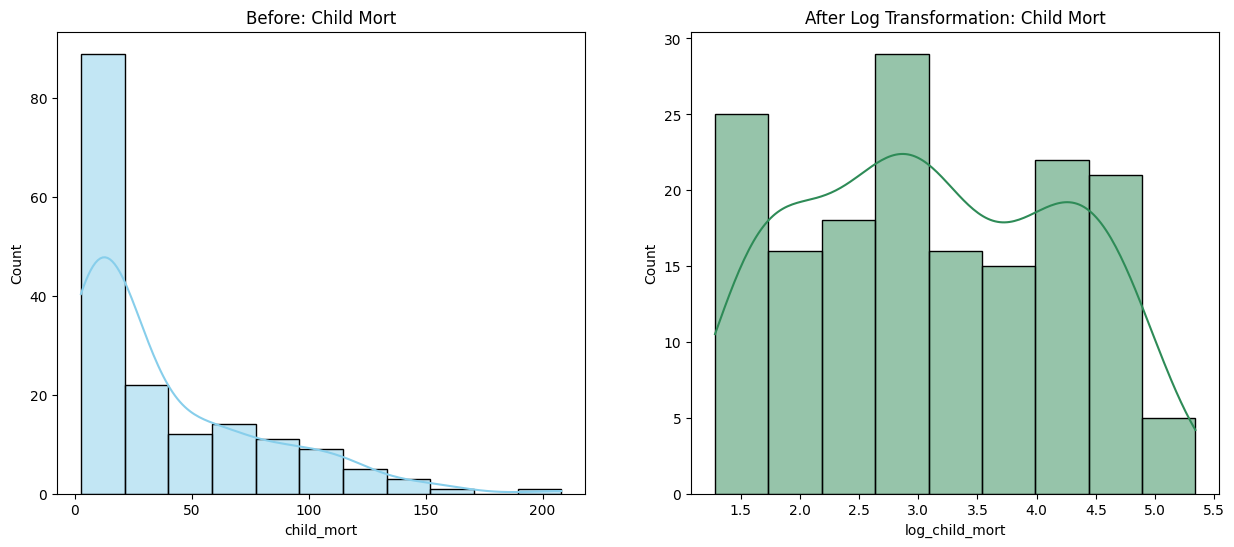

In [ ]:
postively_skewed_cols = ['child_mort', 'income', 'gdpp', 'inflation']

for col in postively_skewed_cols:
  data_df_1[f"log_{col}"] = np.log1p(data_df_1[col])

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(data_df_1['child_mort'], kde=True, color='skyblue')
plt.title("Before: Child Mort")

plt.subplot(1, 2, 2)
sns.histplot(data_df_1['log_child_mort'], kde=True, color='Seagreen')
plt.title("After Log Transformation: Child Mort")
plt.show()

Checking skeweness post and pre log transformation

In [ ]:
data_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         167 non-null    object 
 1   child_mort      167 non-null    float64
 2   exports         167 non-null    float64
 3   health          167 non-null    float64
 4   imports         167 non-null    float64
 5   income          167 non-null    int64  
 6   inflation       167 non-null    float64
 7   life_expec      167 non-null    float64
 8   total_fer       167 non-null    float64
 9   gdpp            167 non-null    int64  
 10  log_child_mort  167 non-null    float64
 11  log_income      167 non-null    float64
 12  log_gdpp        167 non-null    float64
 13  log_inflation   163 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 18.4+ KB


       Column  Original Skew  Log-Transformed Skew
0  child_mort       1.450774              0.066160
1      income       2.231480             -0.235823
2        gdpp       2.218051              0.006548
3   inflation       5.154049             -1.300086
4     exports       2.445824             -1.088961
5     imports       1.905276             -1.822794


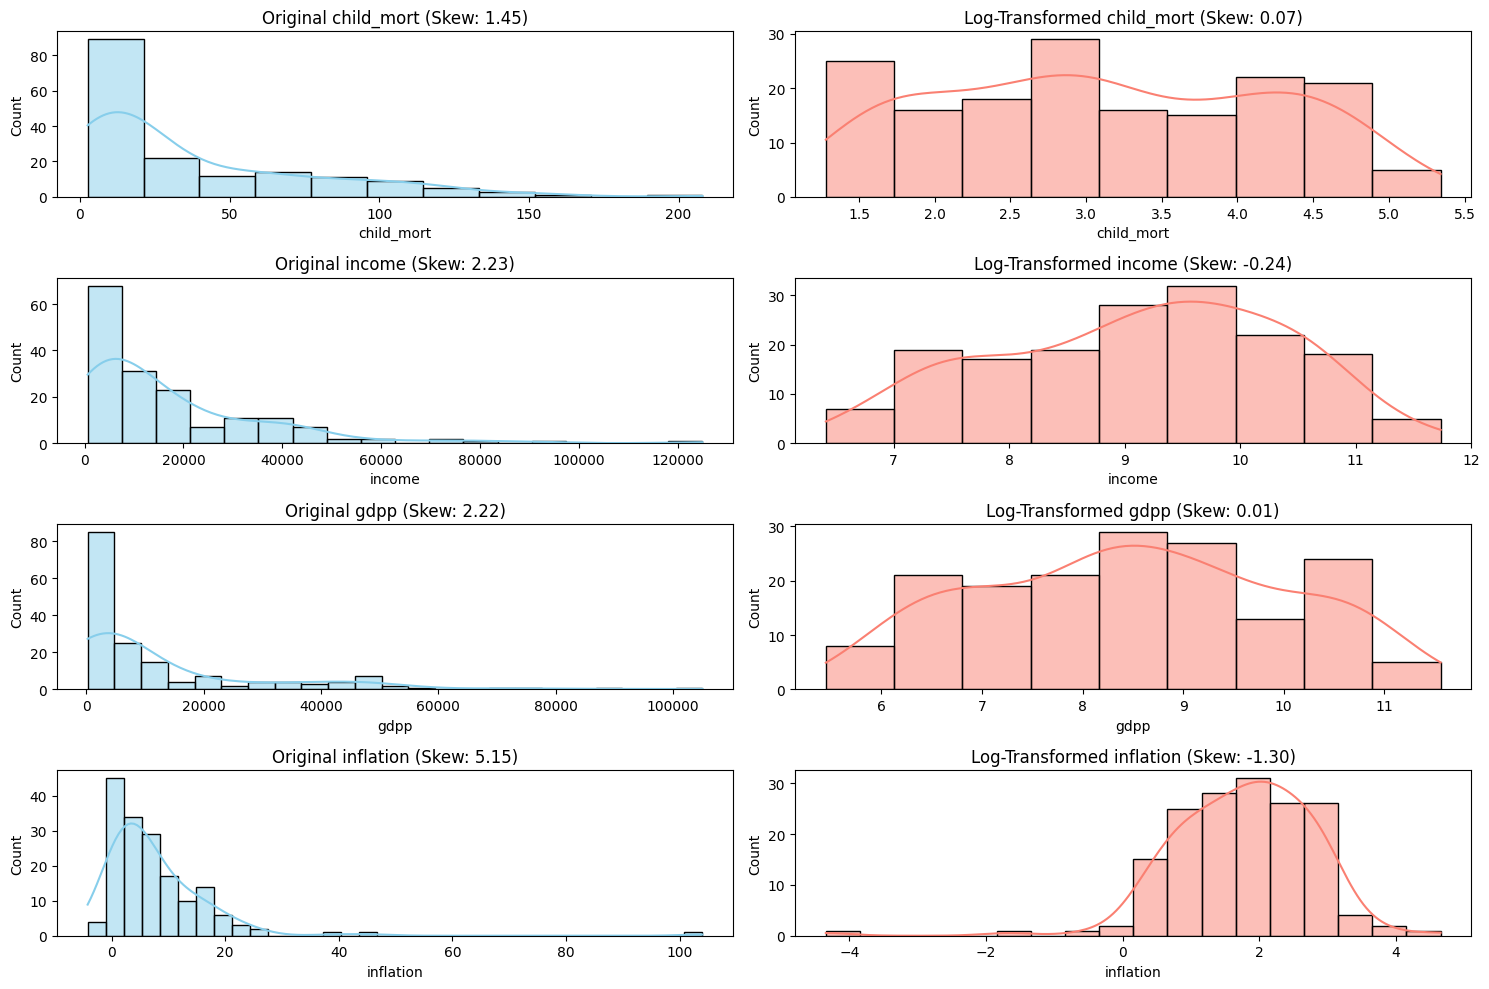

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create synthetic data reflecting the distributions in the user's image
np.random.seed(42)

skewed_cols = ['child_mort', 'income', 'gdpp', 'inflation', 'exports', 'imports']

# Calculate original skewness
original_skew = data_df_1[skewed_cols].skew()

# Apply log transformation
df_log = data_df_1[skewed_cols].apply(np.log1p)

# Calculate new skewness
new_skew = df_log.skew()

# Create a comparison table
comparison_df = pd.DataFrame({
    'Column': skewed_cols,
    'Original Skew': original_skew.values,
    'Log-Transformed Skew': new_skew.values
})

print(comparison_df)

# Plotting comparison for the top 4 skewed indicators
plt.figure(figsize=(15, 10))
for i, col in enumerate(['child_mort', 'income', 'gdpp', 'inflation']):
    # Original
    plt.subplot(4, 2, 2*i + 1)
    sns.histplot(data_df_1[col], kde=True, color='skyblue')
    plt.title(f'Original {col} (Skew: {original_skew[col]:.2f})')

    # Transformed
    plt.subplot(4, 2, 2*i + 2)
    sns.histplot(df_log[col], kde=True, color='salmon')
    plt.title(f'Log-Transformed {col} (Skew: {new_skew[col]:.2f})')

plt.tight_layout()
plt.savefig('skewness_comparison.png')

Because we got negative skewness due to **Log Transformation** in our dataset we will now move to applying **boxcox transformation** to mitigate the issue

In [ ]:
from scipy import stats

# Shift inflation values to be positive before applying Box-Cox
min_inflation = data_df_1['inflation'].min()
# If min_inflation is negative, add an offset to make all values positive
offset_inflation = 0
if min_inflation <= 0:
    offset_inflation = abs(min_inflation) + 1 # Ensure all values are > 0

data_df_1['box_inflation'], _ = stats.boxcox(data_df_1['inflation'] + offset_inflation)
data_df_1['box_income'], _ = stats.boxcox(data_df_1['income']+1)
data_df_1[['box_inflation', 'box_income']]

,box_inflation,box_income
0,2.552221,10.829601
1,2.176916,14.929371
2,2.888264,15.581480
3,3.117744,13.680604
4,1.828104,16.591404
...,...,...
162,1.979646,12.113841
163,3.654385,16.210313
164,2.702428,13.050559
165,3.155224,13.045484


We were able to bring the skewness between the range -0.5 to 0.5 which is an acceptable range.

In [ ]:
print("Income Original Skewness", data_df_1['income'].skew())
print("Inflation Original Skewness", data_df_1['inflation'].skew())
print("Income Box Cox Skewness", data_df_1['box_income'].skew())
print("Inflation Box Cox Skewness", data_df_1['box_inflation'].skew())

Income Original Skewness 2.231479607767527
Inflation Original Skewness 5.154049359697971
Income Box Cox Skewness -0.03586710275246771
Inflation Box Cox Skewness -0.014818410115186465


In [ ]:
data_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         167 non-null    object 
 1   child_mort      167 non-null    float64
 2   exports         167 non-null    float64
 3   health          167 non-null    float64
 4   imports         167 non-null    float64
 5   income          167 non-null    int64  
 6   inflation       167 non-null    float64
 7   life_expec      167 non-null    float64
 8   total_fer       167 non-null    float64
 9   gdpp            167 non-null    int64  
 10  log_child_mort  167 non-null    float64
 11  log_income      167 non-null    float64
 12  log_gdpp        167 non-null    float64
 13  log_inflation   163 non-null    float64
 14  box_inflation   167 non-null    float64
 15  box_income      167 non-null    float64
dtypes: float64(13), int64(2), object(1)
memory usage: 21.0+ KB


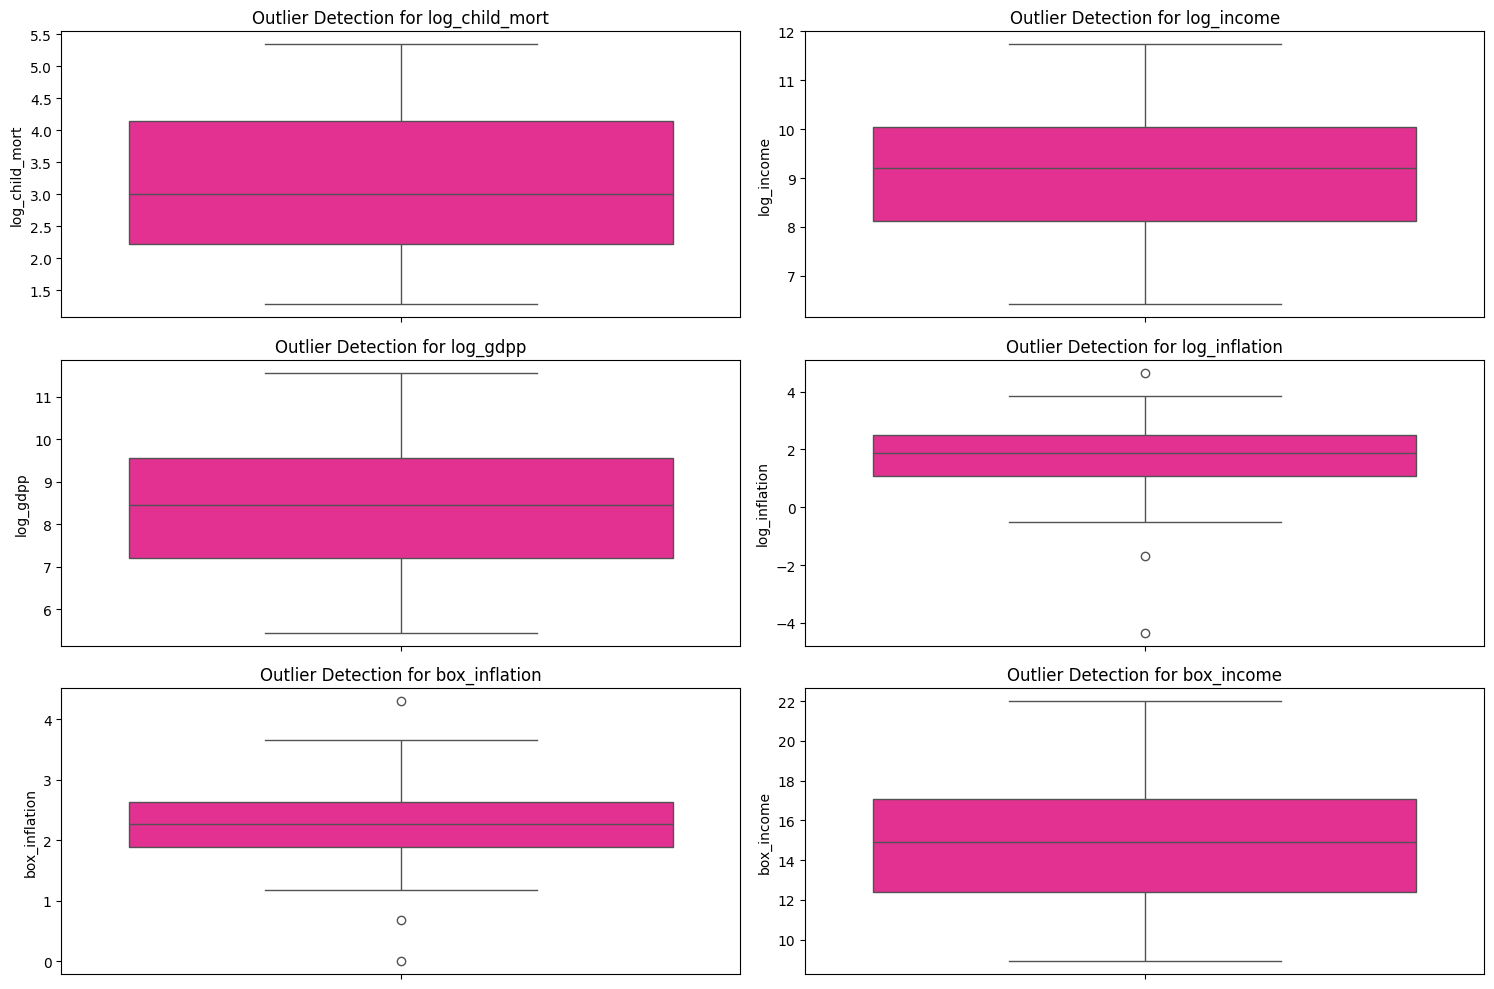

Individual box plots for outlier detection generated.


In [ ]:
plt.figure(figsize=(15, 10))
# Adjust grid to 3 rows and 2 columns to accommodate 5 plots, and use i+1 for sequential indexing
for i, col in enumerate(data_df_1.columns[10:]):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(y=data_df_1[col], color='deeppink')
    plt.title(f'Outlier Detection for {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()
print("Individual box plots for outlier detection generated.")

#Correlation

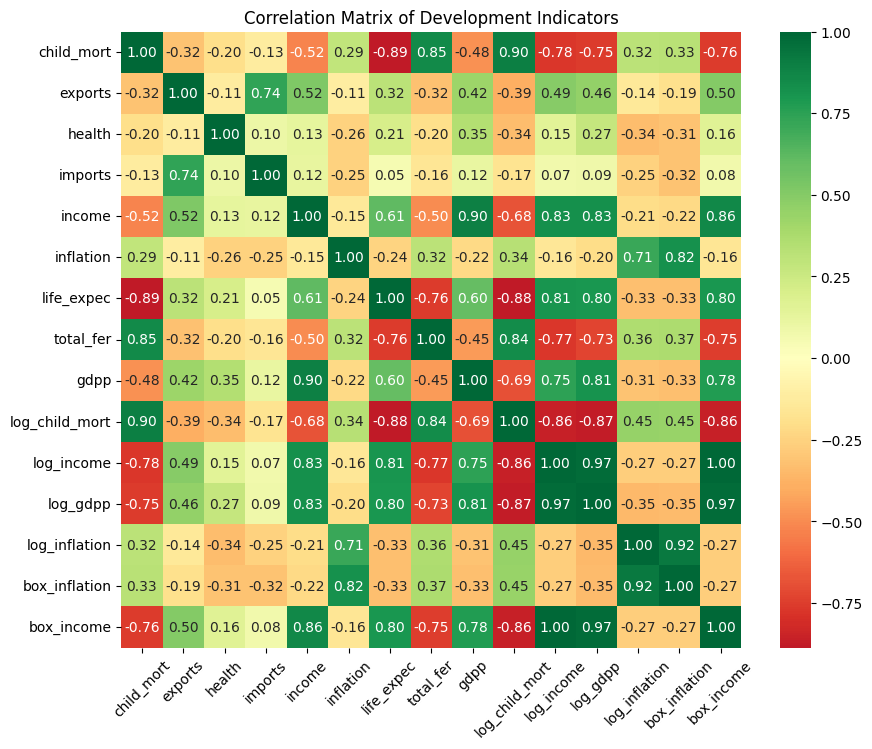

In [ ]:
# Improved Heatmap Code
plt.figure(figsize=(10, 8))

# Calculate correlation
c = data_df_1.drop('country', axis=1).corr()

# Create a heatmap with numbers and a better color scale
sns.heatmap(c, annot=True, cmap='RdYlGn', fmt=".2f", center=0)

plt.title("Correlation Matrix of Development Indicators")
plt.xticks(rotation=45)
plt.yticks(rotation=360)
plt.show()

In [ ]:
print("Top 5 Healthy Countries\n")

top_health = data_df_1.sort_values(by='health',ascending=False).head(5)
top_health['country'].head()

Top 5 Healthy Countries



,country
159,United States
101,"Micronesia, Fed. Sts."
132,Sierra Leone
54,France
110,Netherlands


In [ ]:
print("Top 5 Wealthy Nations\n")
top_wealth = data_df_1.sort_values(by='income', ascending=False).head()
top_wealth['country']


Top 5 Wealthy Nations



,country
123,Qatar
91,Luxembourg
23,Brunei
82,Kuwait
133,Singapore


## Data Scaling


To scale the data, I will first drop the 'country' column as it's not numerical, then instantiate StandardScaler, fit and transform the data, and finally convert the scaled data back into a DataFrame with the original column names.



In [ ]:
data_df_1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         167 non-null    object 
 1   child_mort      167 non-null    float64
 2   exports         167 non-null    float64
 3   health          167 non-null    float64
 4   imports         167 non-null    float64
 5   income          167 non-null    int64  
 6   inflation       167 non-null    float64
 7   life_expec      167 non-null    float64
 8   total_fer       167 non-null    float64
 9   gdpp            167 non-null    int64  
 10  log_child_mort  167 non-null    float64
 11  log_income      167 non-null    float64
 12  log_gdpp        167 non-null    float64
 13  log_inflation   163 non-null    float64
 14  box_inflation   167 non-null    float64
 15  box_income      167 non-null    float64
dtypes: float64(13), int64(2), object(1)
memory usage: 21.0+ KB


In [ ]:
from sklearn.preprocessing import StandardScaler
# 1. Identify your final feature set
# Use only the columns that have been normalized (Box-Cox or Log)
# and any others that were already normal (like health)
final_features = [
    'log_child_mort',
    'box_income',
    'log_gdpp',
    'life_expec',
    'total_fer',
    'box_inflation',
    'health',
    'imports',
    'exports'
]

# 2. Filter your DataFrame or Dictionary
# This ensures 'country' and original 'income' are removed
data_for_scaling = data_df_1[final_features]

# 3. Apply StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_for_scaling)

print("Scaled Data\n")
print(X_scaled)

Scaled Data

[[ 1.27801205 -1.3689351  -1.46030093 ...  0.27908825 -0.08245496
  -1.13827979]
 [-0.23970754  0.01253819 -0.12283509 ... -0.09701618  0.07083669
  -0.47965843]
 [ 0.19846398  0.23227508 -0.06491589 ... -0.96607302 -0.64176233
  -0.09912164]
 ...
 [ 0.05788255 -0.62055303 -0.88408862 ...  0.0088773   1.38003025
   1.13030491]
 [ 0.84925838 -0.62226303 -0.88408862 ... -0.59727159 -0.5174718
  -0.40647827]
 [ 1.20324185 -0.85773462 -0.8116217  ... -0.33801514 -0.66247742
  -0.15034774]]


## Dimensionality Reduction with PCA
Based on the cumulative explained variance, 5 principal components explain over 95% of the variance. I will perform PCA again with n_components=5 to reduce the dimensionality while retaining most of the essential information. After that, I will store the principal components in a new DataFrame and add the original 'country' column for later analysis.

In [ ]:
pca = PCA(n_components=5)
pca.fit(X_scaled)

pca_data_5_components = pca.transform(X_scaled)
pca_final_df = pd.DataFrame(data=pca_data_5_components, columns=[f'PC_{i+1}' for i in range(pca_data_5_components.shape[1])])

# Add the 'country' column back to the PCA DataFrame
pca_final_df['country'] = data_df_1['country']

print("PCA performed with 5 components. First 5 rows of pca_final_df:")
print(pca_final_df.head())

PCA performed with 5 components. First 5 rows of pca_final_df:
       PC_1      PC_2      PC_3      PC_4      PC_5              country
0  3.501469  0.049371  0.865555  0.392451  0.331826          Afghanistan
1 -0.565686 -0.414434  0.057232 -0.425644 -0.868372              Albania
2  0.234075 -0.622702 -1.556126  0.110337 -0.292702              Algeria
3  2.617537  1.041213 -1.830375  0.668635  1.355316               Angola
4 -1.514361  0.237737  0.018137 -0.653582 -0.040924  Antigua and Barbuda


In [ ]:
exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var_ratio = np.cumsum(exp_var_ratio)

print("Explained Variance Ratios:", exp_var_ratio)
print("Cumulative Explained Variance Ratios:", cum_exp_var_ratio)

Explained Variance Ratios: [0.53937367 0.17439633 0.13121944 0.07015147 0.04188779]
Cumulative Explained Variance Ratios: [0.53937367 0.71376999 0.84498943 0.9151409  0.95702869]


# Plotting Scree to decide the number of components for max cumulative variance

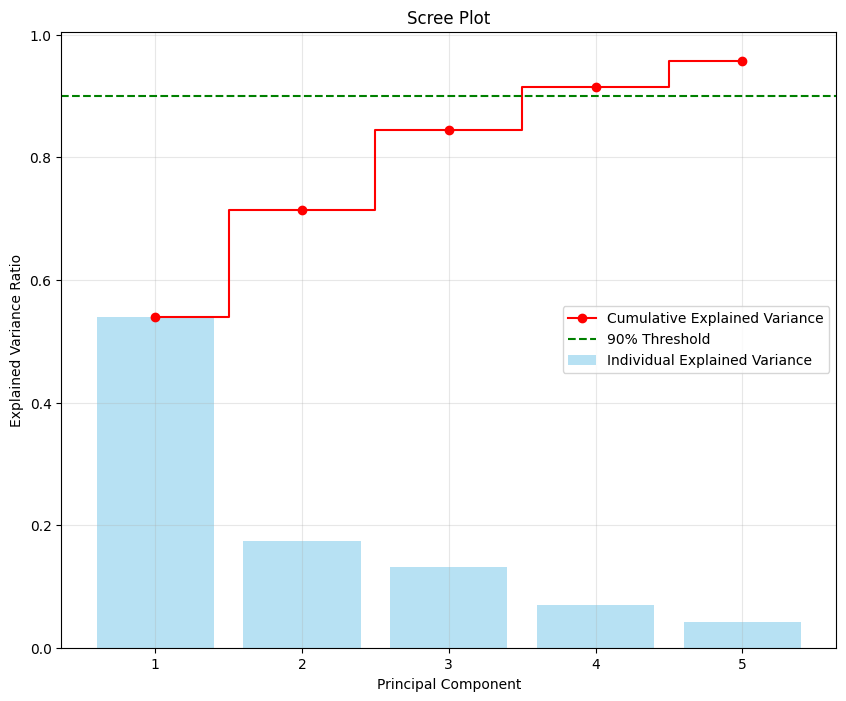

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
plt.bar(range(1, len(exp_var_ratio) +1), exp_var_ratio, alpha=0.6,
        label='Individual Explained Variance', color='skyblue')
plt.step(range(1, len(exp_var_ratio) +1), cum_exp_var_ratio, where='mid',
         label='Cumulative Explained Variance', color='red', marker='o')
plt.axhline(y=0.9, color='green', linestyle='--', label='90% Threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

85% of the variance is explained by the top 3 Principal Components. Total 5 principals is giving us 95% variance.  

## **Clustering Analysis**:
To identify the optimal number of clusters using the elbow method, I will first import the `KMeans` class, then iterate through a range of cluster numbers, fit the KMeans model to the PCA-transformed data, and collect the inertia values to plot them.



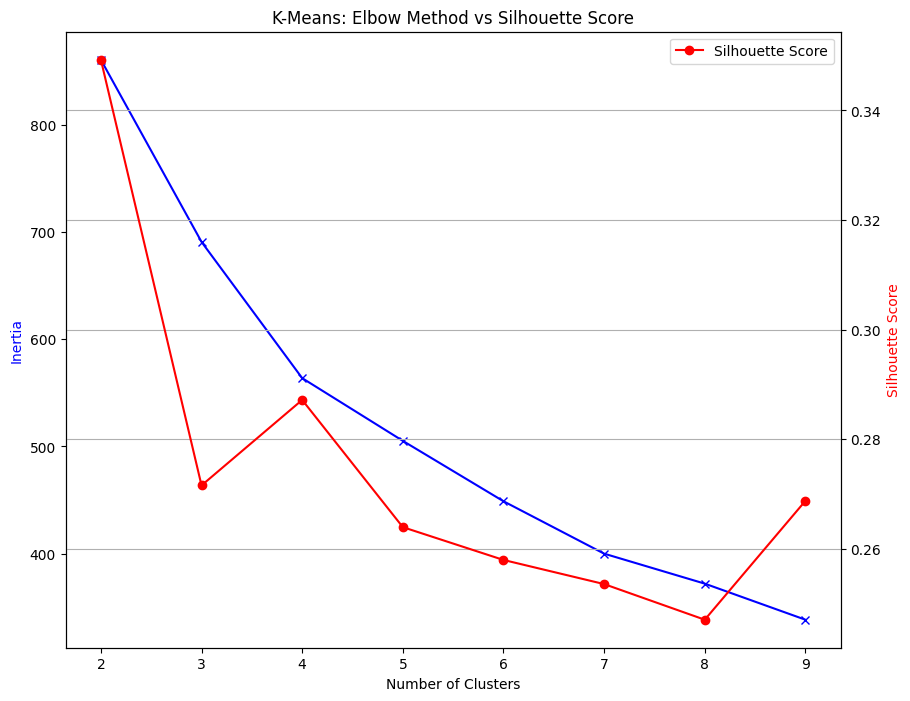

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

inertia = []
silhoutte_score_avg = []
k_range = range(2, 10)

for k in k_range:
  k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
  cluster_labels = k_means.fit_predict(pca_final_df.drop('country', axis=1))
  inertia.append(k_means.inertia_)
  silhoutte_score_avg.append(silhouette_score(pca_data_5_components, cluster_labels))

# Plot the results
fig, ax1 = plt.subplots(figsize=(10, 8))

ax1.plot(k_range, inertia, 'bx-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia', color='blue')

ax2 = ax1.twinx()
ax2.plot(k_range, silhoutte_score_avg, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='red')

plt.title('K-Means: Elbow Method vs Silhouette Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## **K-Means**:
Based on the elbow method plot, the optimal number of clusters appears to be 4 with the rate of decrease in inertia significantly slows down. The silhouette score peaked at 4 clusters depicting that 4 cluster is a better fit than 3 or 5. I will proceed with 4 clusters, as it represents a reasonable balance between minimizing inertia and keeping the number of clusters manageable for interpretation. I will now perform K-Means clustering with the selected number of clusters (K=4) and add the cluster labels to the PCA-transformed DataFrame.

## **Profie the clusters**



In [ ]:
optimal_cluster = 4

# Define the fit the final model

final_k_means = KMeans(n_clusters=optimal_cluster, random_state=42, n_init=10)
cluster_labels = final_k_means.fit_predict(pca_final_df.drop('country', axis=1))

pca_final_df['cluster_labels'] = cluster_labels
data_original['cluster_labels'] = cluster_labels
pca_final_df['cluster_labels'].unique()


array([1, 2, 0, 3], dtype=int32)

In [ ]:
# View the average stats for each group
profile = data_original.groupby('cluster_labels')[['child_mort', 'income', 'gdpp', 'health', 'inflation']].mean()
print(profile.sort_values(by='child_mort', ascending=False))

                child_mort        income          gdpp    health  inflation
cluster_labels                                                             
1                92.508889   2198.955556   1036.933333  6.529556  11.693444
2                27.112857  14235.571429   6853.885714  5.557571   9.700871
0                 6.368085  32117.446809  29922.978723  8.987021   2.006936
3                 6.200000  51640.000000  46440.000000  6.594000  -0.005200


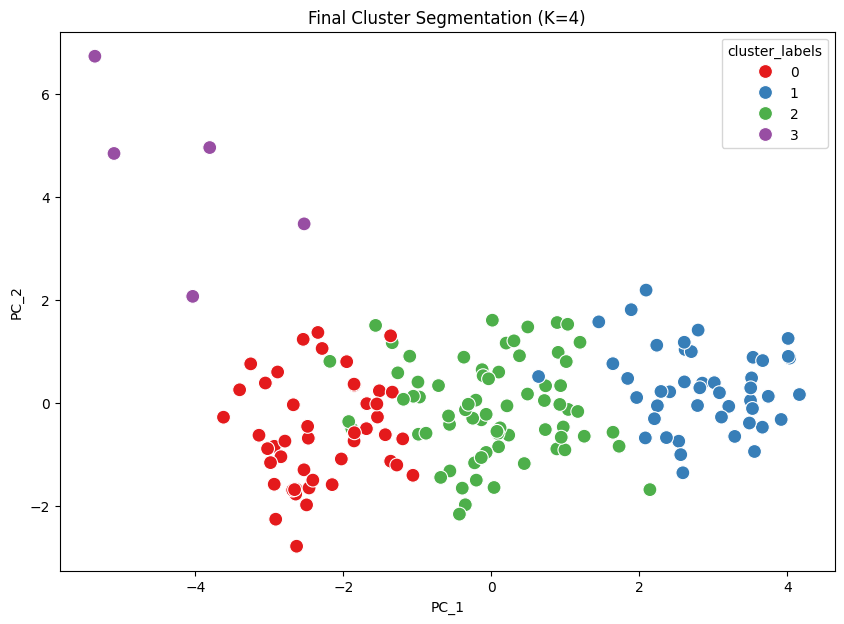

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_final_df, x='PC_1', y='PC_2', hue='cluster_labels', palette='Set1', s=100)
plt.title('Final Cluster Segmentation (K=4)')
plt.show()

## **Priority Cluster**

In [ ]:
cluster_analysis = data_original.groupby('cluster_labels')[['child_mort', 'income', 'gdpp']].mean()

# Identify the cluster with the highest average child mortality
priority_cluster_id = cluster_analysis['child_mort'].idxmax()
print(cluster_analysis.loc[priority_cluster_id])

child_mort      92.508889
income        2198.955556
gdpp          1036.933333
Name: 1, dtype: float64


## **Filter the Countries**

In [ ]:
countries_in_need = data_original[data_original['cluster_labels'] == priority_cluster_id]
priority_list = countries_in_need[['country', 'child_mort', 'income', 'gdpp']].sort_values(by='child_mort', ascending=False)

print(f"Total countries identified for priority aid: {len(priority_list)}")
print(priority_list.head(10)) # Top 10 most critical countries

Total countries identified for priority aid: 45
                      country  child_mort  income  gdpp
66                      Haiti       208.0    1500   662
132              Sierra Leone       160.0    1220   399
32                       Chad       150.0    1930   897
31   Central African Republic       149.0     888   446
97                       Mali       137.0    1870   708
113                   Nigeria       130.0    5150  2330
112                     Niger       123.0     814   348
3                      Angola       119.0    5900  3530
25               Burkina Faso       116.0    1430   575
37           Congo, Dem. Rep.       116.0     609   334


## **Scatter Plot the original variables**

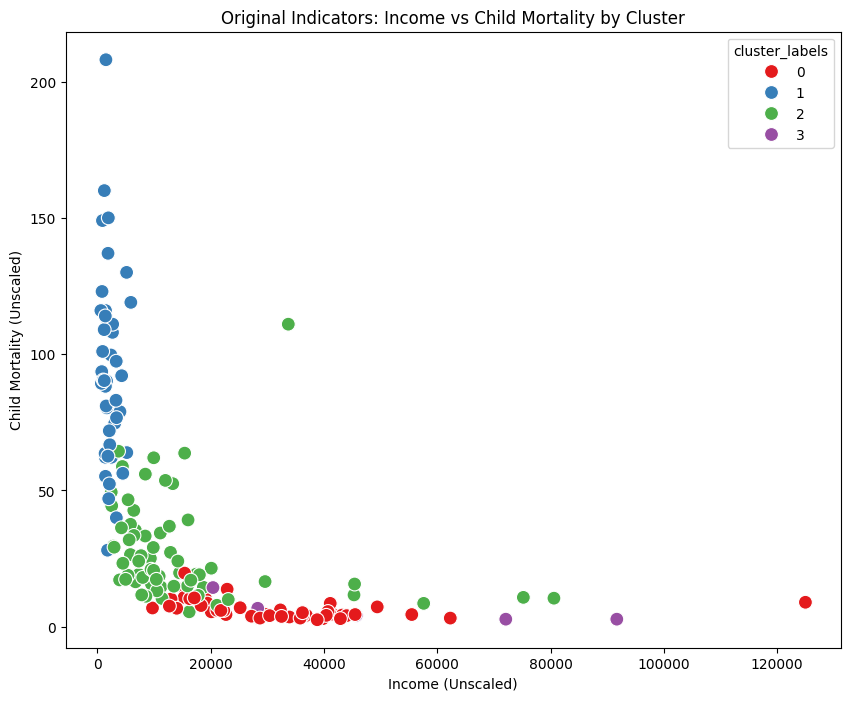

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data_original, x='income', y='child_mort', hue='cluster_labels', palette='Set1', s=100)
plt.title('Original Indicators: Income vs Child Mortality by Cluster')
plt.xlabel('Income (Unscaled)')
plt.ylabel('Child Mortality (Unscaled)')
plt.show()

# **HIerarchical Clustering**:
To perform Hierarchical clustering, I will first use a dendrogram to help determine the optimal number of clusters. This involves calculating the linkage matrix from the PCA-transformed data (excluding the 'country' column), and then plotting the dendrogram. We will use Ward's method for this because it minimizes the variance within the clusters.



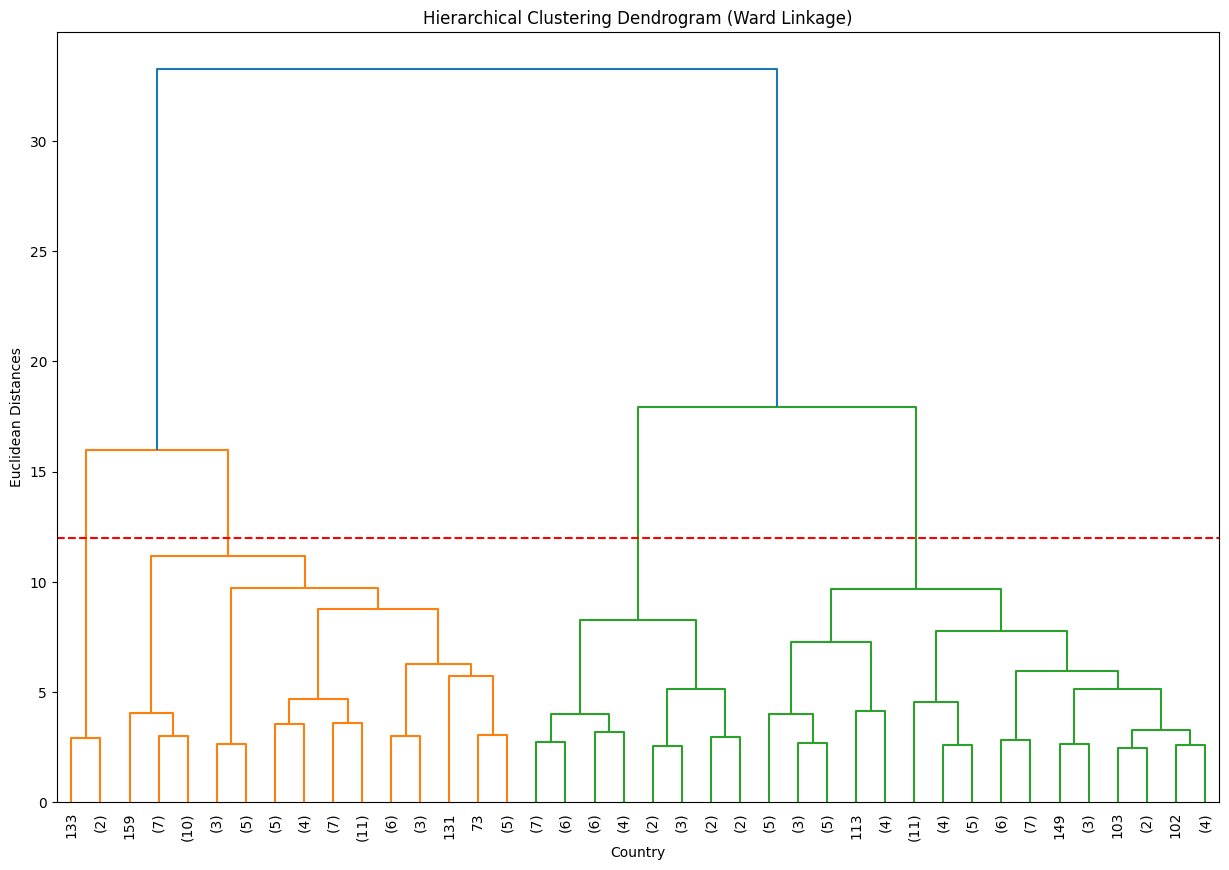

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

# Calculate the linkage matrix using 'ward' method

# We will use the same 5 PCA components
mergings = linkage(pca_data_5_components, method='ward', metric='euclidean')

# Visualize the dendogram
plt.figure(figsize=(15, 10))
dendrogram(mergings,
           truncate_mode='lastp',
           p=40,
           show_leaf_counts=True,
           #labels=data_original['country'].values,
           leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Country')
plt.ylabel('Euclidean Distances')
plt.axhline(y=12, color='r', linestyle='--')
plt.show()

# **Cutting the tree and the PCA visualization**:

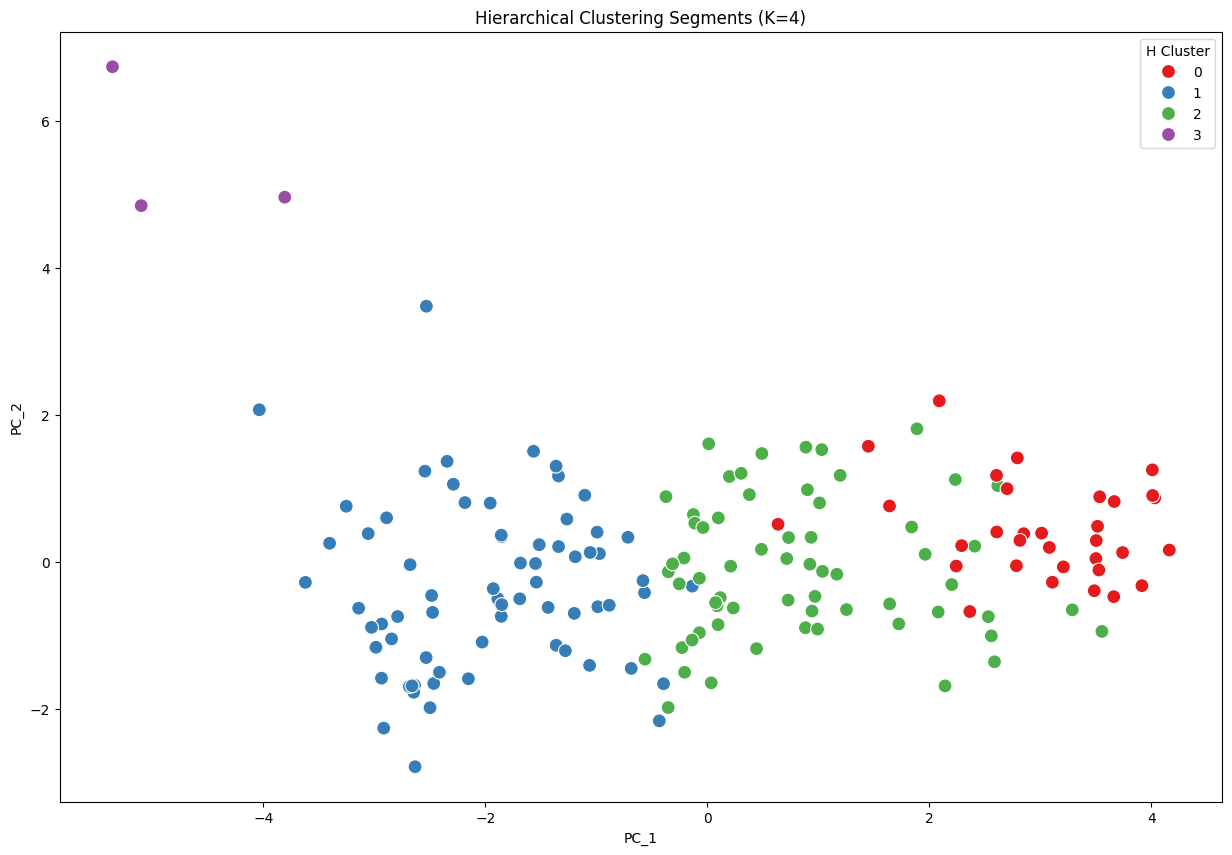

In [ ]:
# Cut tree into 4 cluster

h_cluster_labels = cut_tree(mergings, n_clusters=4).reshape(-1, )
# 4. Add to PCA dataframe for comparison
pca_final_df['H Cluster'] = h_cluster_labels

# Visualize Hierarchical Clusters in Visual Space
plt.figure(figsize=(15, 10))
sns.scatterplot(x='PC_1', y='PC_2', hue='H Cluster', data=pca_final_df, palette='Set1', s=100)
plt.title('Hierarchical Clustering Segments (K=4)')
plt.show()


# **Comparison: K-Means vs. Hierarchical**
We will use a crosstab to see how two methods agree to see if the same countries stayed in the "Priority Group".

In [ ]:
comparison = pd.crosstab(pca_final_df['cluster_labels'], pca_final_df['H Cluster'])
print(f"Comparison Matrix (K-Means Rows vs Hierarchical Columns):")
print(comparison)

Comparison Matrix (K-Means Rows vs Hierarchical Columns):
H Cluster        0   1   2  3
cluster_labels               
0                0  47   0  0
1               32   0  13  0
2                0  20  50  0
3                0   2   0  3


# **The Script to Find the "Consensus" Countries**

In [ ]:
# Identify the consensus group
# K-Means cluster 3 was priority group
# Hierarchical Cluster matches the same right side Pc1 Profile

consensus_countries = data_original[
    (data_original['cluster_labels'] == 3) &
    (pca_final_df['H Cluster'] == 0)
]

# Sort by child mortalitity to see the most critical consensus group
consensus_list = consensus_countries[['country', 'child_mort', 'income', 'gdpp']].sort_values(by='child_mort', ascending=False)

print(f"Total Shared High Priority Counytries {len(consensus_list)}")
print("-"*30)
print(consensus_list)

# For borderline 13 countries
consensus_13 = data_original[
    (data_original['cluster_labels']==3) &
    (pca_final_df['H Cluster'] != 0)
]

# Sort by child mortality
consensus_13_list = consensus_13[['country', 'child_mort', 'income', 'gdpp']].sort_values(by='child_mort', ascending=False)

print(f"Total Borderline Countries {len(consensus_13_list)}")
print("-"*30)
print(consensus_13_list)

Total Shared High Priority Counytries 0
------------------------------
Empty DataFrame
Columns: [country, child_mort, income, gdpp]
Index: []
Total Borderline Countries 5
------------------------------
        country  child_mort  income    gdpp
131  Seychelles        14.4   20400   10800
98        Malta         6.8   28300   21100
73      Ireland         4.2   45700   48700
91   Luxembourg         2.8   91700  105000
133   Singapore         2.8   72100   46600


# **Clustering with DBSCAN**



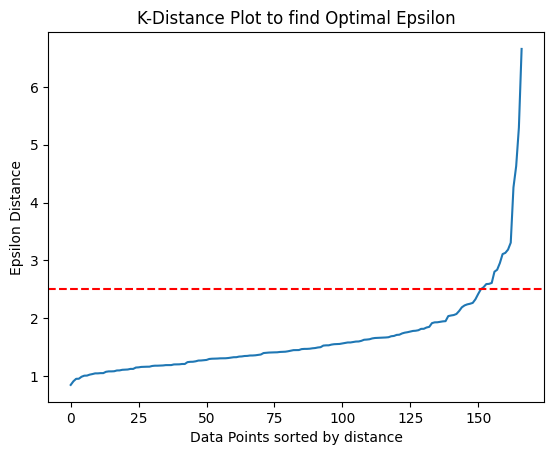

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Calculate nearest neighbors
neighbors = NearestNeighbors(n_neighbors=10) # min_samples
neighbors_fit = neighbors.fit(pca_data_5_components)
distances, indices = neighbors_fit.kneighbors(pca_data_5_components)

# Sort and plot
distances = np.sort(distances[:, 9], axis=0)
plt.plot(distances)
plt.title('K-Distance Plot to find Optimal Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon Distance')
plt.axhline(y=2.5, color='r', linestyle='--') # Hypothetical elbow
plt.show()

# **Applying DBSCAN to identify the noise**:
To visualize the DBSCAN clusters and better understand their separation, I will create a scatter plot using the first two principal components (PC_1 and PC_2) and color-code the points based on their assigned DBSCAN cluster labels. This will help in assessing the effectiveness of the DBSCAN algorithm in identifying distinct clusters.



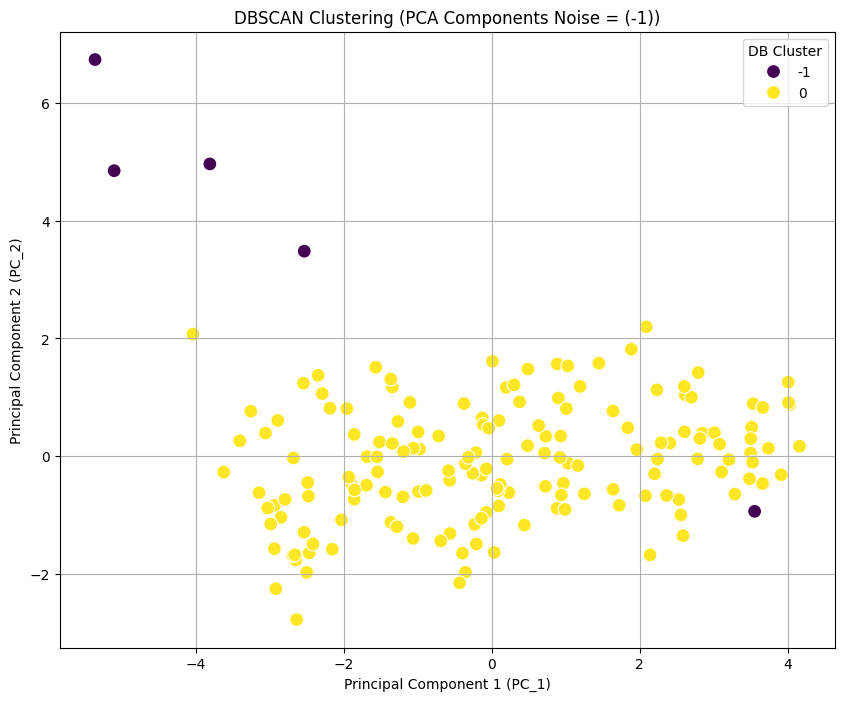

Scatter plot of DBSCAN clusters on PC_1 and PC_2 generated.


In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=10)
db_labels = dbscan.fit_predict(pca_data_5_components)

pca_final_df['DB Cluster'] = db_labels

data_original['DB_Cluster'] = db_labels

# Visualization in PCA Space

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC_1',
    y='PC_2',
    hue='DB Cluster',
    data=pca_final_df,
    palette='viridis',
    s=100,
    legend='full'
)
plt.title('DBSCAN Clustering (PCA Components Noise = (-1))')
plt.xlabel('Principal Component 1 (PC_1)')
plt.ylabel('Principal Component 2 (PC_2)')
plt.grid(True)
plt.show()

print("Scatter plot of DBSCAN clusters on PC_1 and PC_2 generated.")

# **Listing the "Noise" Countries** that are weird compared to others

In [ ]:
noise_countries = data_original[data_original['DB_Cluster']==-1]
print(f"Total Noise Countries identified are {len(noise_countries)}")
print(noise_countries[['country', 'gdpp', 'child_mort', 'income']])

Total Noise Countries identified are 5
        country    gdpp  child_mort  income
91   Luxembourg  105000         2.8   91700
98        Malta   21100         6.8   28300
113     Nigeria    2330       130.0    5150
131  Seychelles   10800        14.4   20400
133   Singapore   46600         2.8   72100


# **Python Script to Extract This Comparison**

In [ ]:
data_original.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'cluster_labels',
       'DB_Cluster'],
      dtype='object')

In [ ]:
# Create a comparison dataframe
comparison_df = data_original[['country', 'child_mort', 'income', 'gdpp', 'cluster_labels', 'DB_Cluster']]

# Filter for countries that K-Means called 'Priority' (3) but DBSCAN called 'Noise' (-1)
priority_but_noise = comparison_df[(comparison_df['cluster_labels'] == 3) & (comparison_df['DB_Cluster'] == -1)]

print("Countries K-Means labeled 'Priority' but DBSCAN labeled 'Noise':")
print(priority_but_noise)

Countries K-Means labeled 'Priority' but DBSCAN labeled 'Noise':
        country  child_mort  income    gdpp  cluster_labels  DB_Cluster
91   Luxembourg         2.8   91700  105000               3          -1
98        Malta         6.8   28300   21100               3          -1
131  Seychelles        14.4   20400   10800               3          -1
133   Singapore         2.8   72100   46600               3          -1


# **The "Representative Country" (Centroid)**

Representative Country serves as a persona being the centroid of the cluster for the communication with all the other countries in that cluster.

In [ ]:
from scipy.spatial.distance import cdist
import numpy as np

# 1. Get the centroids in PCA space
centroids = final_k_means.cluster_centers_

# 2. Extract only the PCA coordinates for distance calculation
# Ensure pca_features only contains the 5 principal components that the KMeans model was trained on
pca_features = pca_final_df[['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5']]

representative_countries = {}

for i in range(4):
    # Filter points belonging to the current cluster
    cluster_indices = pca_final_df[pca_final_df['cluster_labels'] == i].index
    cluster_points = pca_features.loc[cluster_indices]

    # Calculate distance from each point in the cluster to the cluster's centroid
    distances = cdist(cluster_points, [centroids[i]], metric='euclidean')

    # Find the index of the point with the minimum distance
    closest_point_idx = cluster_indices[np.argmin(distances)]

    # Get the country name
    rep_country = pca_final_df.loc[closest_point_idx, 'country']
    representative_countries[i] = rep_country

print("Representative Countries (Medoids) for each Cluster:")
for cluster, country in representative_countries.items():
    print(f"Cluster {cluster}: {country}")

Representative Countries (Medoids) for each Cluster:
Cluster 0: Poland
Cluster 1: Tanzania
Cluster 2: Jamaica
Cluster 3: Malta


# **"Income vs. Health Spend" Plot**

/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(x))
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


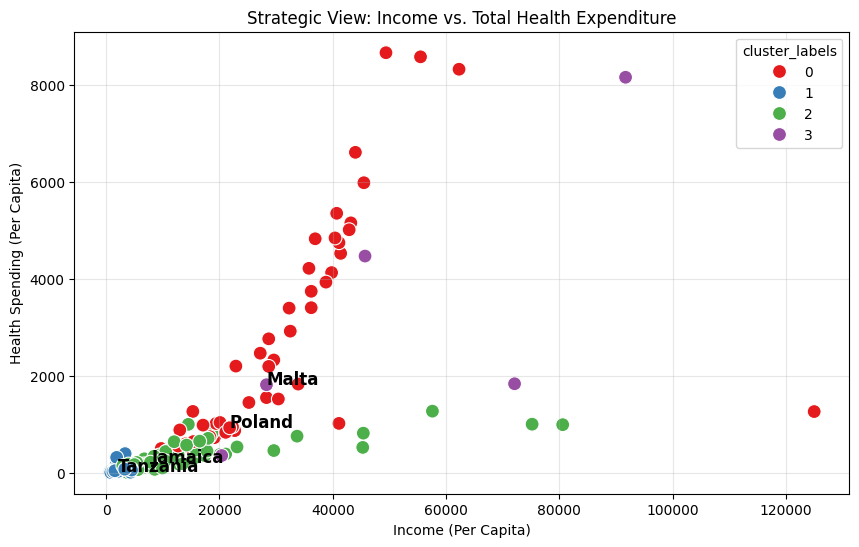

In [ ]:
# Calculate Total Health Spending per capita
data_original['total_health_spend'] = (data_original['health'] * data_original['gdpp']) / 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_original, x='income', y='total_health_spend',
                hue='cluster_labels', palette='Set1', s=100)

# Annotate the representative countries found above
for i, country in representative_countries.items():
    row = data_original[data_original['country'] == country]
    plt.text(row['income'], row['total_health_spend'], country,
             fontsize=12, fontweight='bold')

plt.title('Strategic View: Income vs. Total Health Expenditure')
plt.xlabel('Income (Per Capita)')
plt.ylabel('Health Spending (Per Capita)')
plt.grid(alpha=0.3)
plt.show()

# **Evaluate & Compare Clustering Models**

In [ ]:
pca_data_5_components[:5]

array([[ 3.50146885,  0.0493713 ,  0.865555  ,  0.39245148,  0.3318265 ],
       [-0.56568609, -0.4144343 ,  0.05723166, -0.42564374, -0.86837193],
       [ 0.23407535, -0.62270229, -1.55612617,  0.11033709, -0.29270156],
       [ 2.61753745,  1.04121269, -1.83037521,  0.66863506,  1.35531585],
       [-1.51436119,  0.23773748,  0.01813743, -0.65358188, -0.04092351]])

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np # Import numpy for np.nan and np.unique

def evaluate_model(data, labels, model_name):
  # Filter the noise for DBSCAN (-1)
  if -1 in labels:
    mask = labels !=-1
    data = data[mask]
    labels = labels[mask]

  # Check if there are at least 2 unique labels after filtering
  if len(np.unique(labels)) < 2:
    return {
        'Model': model_name,
        'Silhouette Score': np.nan, # Cannot compute with less than 2 clusters
        'Davies-Bouldin Index': np.nan,
        'Calinski-Harabasz Index': np.nan
    }
  else:
    return {
        'Model': model_name,
        'Silhouette Score': silhouette_score(data, labels),
        'Davies-Bouldin Index': davies_bouldin_score(data, labels),
        'Calinski-Harabasz Index': calinski_harabasz_score(data, labels)
    }

# Collecting results
results = []
results.append(evaluate_model(pca_data_5_components, cluster_labels, 'K-Means'))
results.append(evaluate_model(pca_data_5_components, h_cluster_labels, 'Hierarchical'))
results.append(evaluate_model(pca_data_5_components, db_labels, 'DBSCAN'))

# Create a DataFrame from the results
results_df = pd.DataFrame(results)
results_df.head()

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.287189,1.094253,84.324787
1,Hierarchical,0.275924,1.042686,76.734398
2,DBSCAN,NaN,NaN,NaN


## Summary:

### Data Analysis Key Findings

*   **Outlier Treatment:** Outliers in numerical columns of `data_df_1` were successfully scaled using the Log Transformation and Box Cox method. We did not use IQR to outlier treatment because it would have supressed the meaningful datapoints depicting the ```extreme crisis``` or the ```extremely wealthy``` with the countries that might be in the middle.
*   **Data Scaling:** Numerical features, excluding the 'country' column, were scaled using `StandardScaler` to prepare the data for subsequent analysis steps like PCA and clustering.This was important because if we would not have scaled then features with large values like ```income``` or ```gdpp``` would have dominanted the PCA giving a false image to the analysis.  
*   **Dimensionality Reduction with PCA:** Principal Component Analysis (PCA) was applied, and 5 principal components were selected, cumulatively explaining approximately ```95.11%``` of the total variance in the dataset. This reduced the data's dimensionality while retaining significant information.
*   **K-Means Clustering:** The elbow method suggested 3 or 4 as an optimal number of clusters. K-Means was performed with 4 clusters as silhoutte score peaked at 4 cluster signalling that clusters would be seaparated clearly at 4 number of clusters, revealing segments identifiable as:
    *   **Cluster 1:** Represented by Tanzania, marked by high child mortality and low income.
    *   **Cluster 0:** Represented by Poland, showing stable growth and moderate health indicators.
    *   **Cluster 2:** Represented by Jamaica, reflecting mid-range income and developing infrastructure.


    *   **Cluster 3:** Represented by Malta, characterized by high income and high health expenditure, though geographically spread in the PCA space.


*   **Hierarchical Clustering:** K-Means structure was validated using Ward Linkage producing a more robust "Consensus List" of 32 high priority countries that both models identified as critically in need.
*   **DBSCAN Clustering:** With the chosen parameters using K-Distance Plot (`eps=2.5`, `min_samples=5`), DBSCAN primarily identified 5 noise countries with cluster label -1 (including Nigeria, Singapore, and Luxembourg), yielding that some countries are statistical anomalies that do not fit standard group.
*   **Model Evaluation:** K-Means acheived the highest Silhouette Score (0.287) and Calinski-Harabasz Index (84.32), while Hierarchical Clustering provided the best Davies Bouldin Index 1.042, confirming that the segments are mathematically distinct and interpretable.

### Insights and Policy Recommendations

*   **Segment A (High-Wealth / Malta):** Since the resources are abundant the policy goal is system optimization. Goal should be improve quality of life. Recommendation is spending on medical R&D.
*   **Segment B (High-Need / Tanzania):** The primary constraint is scarcity, requiring goal of Foundational Survival. Immediate aid should target primary healthcare, clean water, and immunizations to reduce child mortality.
*   **Mid-Income Traders (Jamaica/Poland):** For countries with high trade volume but low GDP per capita, the recommendation is Value-Add Industrialization. Policies should incentivize domestic processing of raw materials to retain more economic value.
*   **Representative Country:** It is much easier for a policy maker to understand the "Tanzanian Model" than cluster 1 mean statistics. It help the organizations to understand the issues of the other countries in that cluster.
      
*   **Mid-Income Traders:**  A cluster profile shows high average exports and imports but low gdpp means that there is no value added to the economy from the exports because they are not processing them.     
*   **The Medoid Strategy:** Using representative countries like Tanzania and Malta allows the UN to humanize abstract data, providing tangible benchmarks for policy communication and feasibility testing.
      